In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
# Generate synthetic dataset
def generate_dataset(num_samples=10000, height=5, width=100):
    X = np.random.rand(num_samples, height, width).astype(np.float32)
    y = np.random.choice([-1, 1], size=num_samples)
    # Convert labels to binary (0 and 1)
    y = (y + 1) // 2
    return X, y

In [3]:
# Generate the dataset
X, y = generate_dataset()
print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (10000, 5, 100)
Output shape: (10000,)


In [5]:
X

array([[[0.1769908 , 0.20227228, 0.86471796, ..., 0.23845544,
         0.53775483, 0.2235445 ],
        [0.5801583 , 0.9209235 , 0.49620777, ..., 0.4372871 ,
         0.29042602, 0.52657807],
        [0.66055775, 0.9887847 , 0.83481836, ..., 0.56661123,
         0.26058805, 0.2896832 ],
        [0.46341217, 0.7376862 , 0.6953    , ..., 0.79434997,
         0.6879685 , 0.96423274],
        [0.4858685 , 0.18473119, 0.76614535, ..., 0.9314035 ,
         0.7012171 , 0.54253197]],

       [[0.6121546 , 0.06937044, 0.14114377, ..., 0.8522259 ,
         0.34173918, 0.5035624 ],
        [0.79575443, 0.6783529 , 0.4071931 , ..., 0.62404835,
         0.21363631, 0.979966  ],
        [0.371038  , 0.68866235, 0.92100364, ..., 0.9843973 ,
         0.6572727 , 0.31057233],
        [0.7984201 , 0.5126547 , 0.5208738 , ..., 0.2518803 ,
         0.61598575, 0.17405547],
        [0.05808163, 0.8000977 , 0.22775094, ..., 0.3970896 ,
         0.37391344, 0.27422345]],

       [[0.5077329 , 0.6018741 , 0.3

In [6]:
y

array([0, 1, 0, ..., 1, 0, 1])

In [14]:
# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.66, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [15]:
print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (3400, 5, 100) (3400,)
Validation set shape: (3300, 5, 100) (3300,)
Test set shape: (3300, 5, 100) (3300,)


In [16]:
# Convert numpy arrays to PyTorch tensors
X_train = torch.from_numpy(X_train).unsqueeze(1)
X_val = torch.from_numpy(X_val).unsqueeze(1)
X_test = torch.from_numpy(X_test).unsqueeze(1)
y_train = torch.from_numpy(y_train).float()
y_val = torch.from_numpy(y_val).float()
y_test = torch.from_numpy(y_test).float()

In [17]:
# Define the model
class DeepClassifier(nn.Module):
    def __init__(self):
        super(DeepClassifier, self).__init__()
        self.conv = nn.Conv2d(1, 50, kernel_size=(5, 10), padding='same')
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(1, 5))
        self.dropout = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(25 * 5 * 40, 64) # not sure about this dimension
        self.fc2 = nn.Linear(64, 1) # not sure about this dimension
        self.sigmoid = nn.Sigmoid() # need to check with the paper

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

In [18]:
# Initialize the model, loss function, and optimizer
model = DeepClassifier()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

In [20]:
# Evaluation function
def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        loss = criterion(outputs.squeeze(), y)
        predicted = (outputs.squeeze() > 0.5).float()
        accuracy = (predicted == y).float().mean()
    return loss.item(), accuracy.item()

In [26]:
# Training loop
num_epochs = 100
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

In [27]:
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs.squeeze(), y_train)
    loss.backward()
    optimizer.step()
    
    # Evaluate on training and validation sets
    train_loss, train_accuracy = evaluate(model, X_train, y_train)
    val_loss, val_accuracy = evaluate(model, X_val, y_val)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

Epoch [10/100], Train Loss: 0.6936, Train Acc: 0.5000, Val Loss: 0.6939, Val Acc: 0.4970
Epoch [20/100], Train Loss: 0.6936, Train Acc: 0.5000, Val Loss: 0.6938, Val Acc: 0.4970
Epoch [30/100], Train Loss: 0.6936, Train Acc: 0.5000, Val Loss: 0.6938, Val Acc: 0.4970
Epoch [40/100], Train Loss: 0.6935, Train Acc: 0.5000, Val Loss: 0.6937, Val Acc: 0.4970
Epoch [50/100], Train Loss: 0.6935, Train Acc: 0.5000, Val Loss: 0.6937, Val Acc: 0.4970
Epoch [60/100], Train Loss: 0.6934, Train Acc: 0.5000, Val Loss: 0.6936, Val Acc: 0.4970
Epoch [70/100], Train Loss: 0.6934, Train Acc: 0.5000, Val Loss: 0.6935, Val Acc: 0.4970
Epoch [80/100], Train Loss: 0.6934, Train Acc: 0.5000, Val Loss: 0.6935, Val Acc: 0.4970
Epoch [90/100], Train Loss: 0.6933, Train Acc: 0.5000, Val Loss: 0.6934, Val Acc: 0.4970
Epoch [100/100], Train Loss: 0.6933, Train Acc: 0.5000, Val Loss: 0.6934, Val Acc: 0.4970


In [28]:
# Evaluate on test set
test_loss, test_accuracy = evaluate(model, X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6936, Test Accuracy: 0.4900


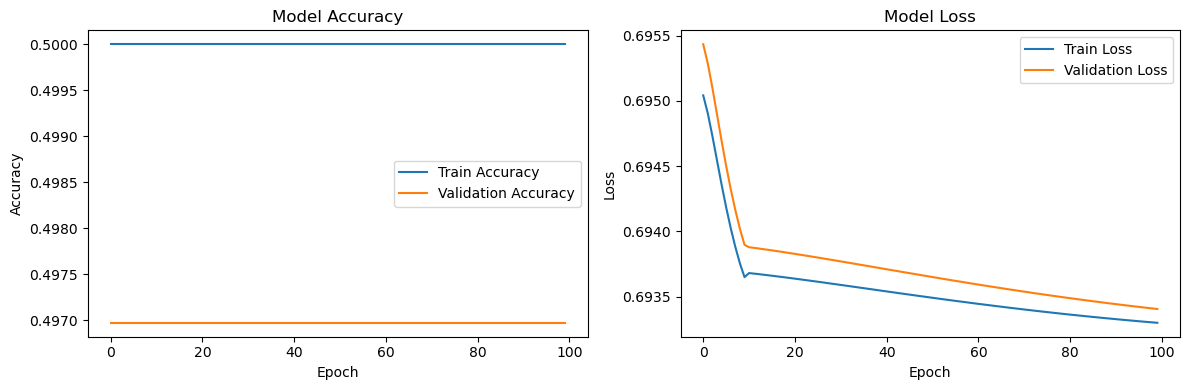

In [29]:
# Visualize training process
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()